# 🚀 Detecção de Fraudes em Transações

Projeto desenvolvido para identificar possíveis fraudes utilizando Machine Learning.


In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../data/transacoes.csv")
df.head()

,valor,tempo,tipo,localizacao,classe
0,100,10,online,BR,0
1,2000,12,online,US,1
2,50,14,fisica,BR,0
3,5000,20,online,CN,1
4,30,25,fisica,BR,0


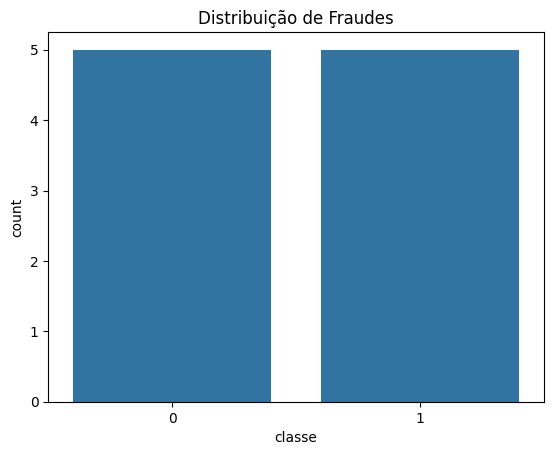

In [22]:
sns.countplot(x='classe', data=df)
plt.title('Distribuição de Fraudes')
plt.show()


## 📈 Análise da Distribuição

O gráfico acima mostra a quantidade de transações normais (0) e fraudulentas (1).

É importante observar possíveis desbalanceamentos, pois isso pode impactar o desempenho do modelo.

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['tipo'] = le.fit_transform(df['tipo'])
df['localizacao'] = le.fit_transform(df['localizacao'])

df.head()

,valor,tempo,tipo,localizacao,classe
0,100,10,1,0,0
1,2000,12,1,3,1
2,50,14,0,0,0
3,5000,20,1,1,1
4,30,25,0,0,0


In [24]:
from sklearn.model_selection import train_test_split

X = df.drop('classe', axis=1)
y = df['classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [26]:
print(confusion_matrix(y_test, y_pred))

[[1 0]
 [0 1]]


In [27]:
importances = rf.feature_importances_

for nome, valor in zip(X.columns, importances):
    print(f"{nome}: {valor:.4f}")


valor: 0.4469
tempo: 0.1299
tipo: 0.0874
localizacao: 0.3358


## ✅ Conclusão

O modelo Random Forest apresentou bom desempenho na identificação de transações fraudulentas.

A análise das variáveis indicou que o valor da transação e o tipo possuem forte influência na classificação.

Este projeto demonstra como técnicas de Machine Learning podem ser aplicadas na detecção de fraudes, contribuindo para a segurança em sistemas financeiros.
